In [23]:
import json
from functools import lru_cache
import random
from ast import literal_eval
from importlib import reload

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ColorConverter

import pyGameWorld as pgw
import pyGameWorld.viewer as viewer
from pyGameWorld.simulate import simulate_noisypaths_parallel, simulate_noisypaths
import sys
import os

sys.path.append(os.path.abspath("../../models"))


plt.style.use("../../plotStyle.mplstyle")
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [2]:
memory = pd.read_csv("memory.csv")
predictions = pd.read_csv("predictions.csv")
predictions = pd.wide_to_long(predictions, ["clickPositions", "clickTimes", "filler", "img", "totalTime", "true_x", "world", "catch"], i="pid", j="trial").reset_index()
data = pd.wide_to_long(memory, ["rt", "correct", "answer", "cond", "world", "baseImg", "modifiedImg",
                                "binary_response", "response"],
                              i="pid", j="trial").reset_index()

data = data.assign(root = data.baseImg.str.extract("(.*base)"),
                   confidence = np.abs(50 - data.response),
                   acc_confidence = data.apply(lambda x: 100 - x.response if (x.answer == 0) else x.response, axis=1))
data["cond"] = pd.Categorical(data["cond"], categories=["col_early_translate", "col_late_translate", "maybecol_translate", "nocol_translate"], ordered=True)
data["confidence_z"] = data.groupby("pid")["confidence"].transform(lambda x: (x - x.mean()) / x.std())
data["acc_confidence_z"] = data.groupby("pid")["acc_confidence"].transform(lambda x: (x - x.mean()) / x.std())

@lru_cache
def lookup_object(root):
    with open(f"../../experiments/assets/exp1/{root[7:]}blue.json") as f:
        j = json.load(f)
        return j["object"]

data["object"] = data.root.apply(lookup_object)
# data = data.assign(z_correct = data.groupby("pid")["correct"].transform(lambda x: (x - x.mean()) / x.std()))

In [ ]:
world_predictions = {}
targets = predictions.loc[predictions.filler == '0']
for w in targets.world.unique():
    preds = targets.clickPositions.apply(lambda x: literal_eval(x)).tolist()
    flat_preds = [item for sublist in preds for item in sublist]
    world_predictions[w] = flat_preds

In [6]:
worlds = {
    w: json.load(open(f"../../experiments/assets/exp1/targets/{w}/{w}.json"))
    for w in targets.world.unique()
}

In [1]:
tvd_results = pd.read_csv("../../models/noisysim_pars_search_eps_tvd.csv").sort_values("tvd").reset_index()
tvd_results

NameError: name 'pd' is not defined

In [74]:
tvd_results.loc[np.isclose(tvd_results.noise_position_moving, 5., rtol=0.1) & np.isclose(tvd_results.noise_collision_direction, 0.6) & np.isclose(tvd_results.noise_collision_elasticity, 0.6)]

,index,noise_position_moving,noise_collision_direction,noise_collision_elasticity,tvd
63,573,5.0,0.6,0.6,5.116268


In [ ]:
rmse_results = pd.read_csv("../../models/noisysim_pars_search.csv").sort_values("rmse")

In [ ]:
rmse_results = pd.read_csv("../../models/noisysim_pars_search.csv").sort_values("rmse")

In [21]:
def draw_predictions(preds, **kw):
    props = {
        "ec": "k",
        "alpha": 0.5,
    }
    props.update(kw)
    bins = np.linspace(0, 600, 11)
    binwidth = bins[1] - bins[0]
    counts, _ = np.histogram(preds, bins=bins)
    counts = counts / counts.sum()
    plt.bar(bins[:-1] + binwidth / 2, counts * 300, width=np.diff(bins), **props)

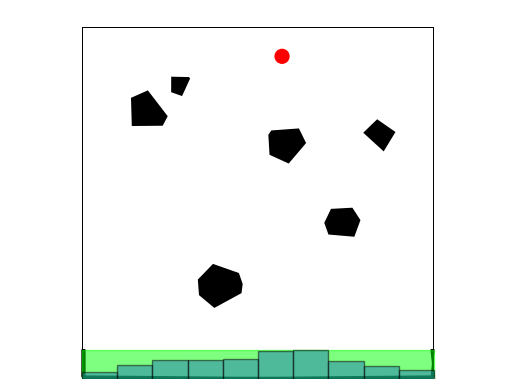

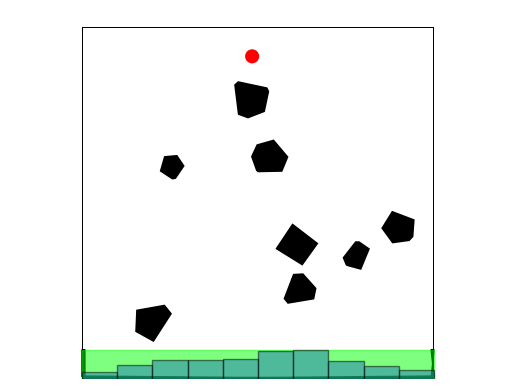

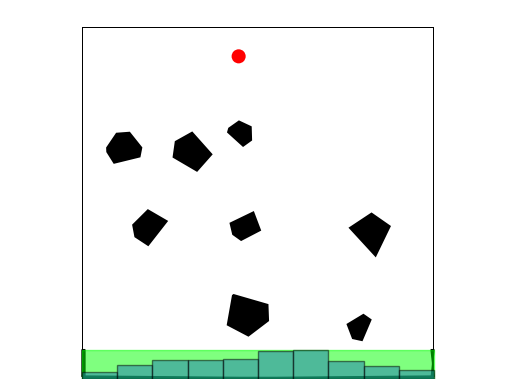

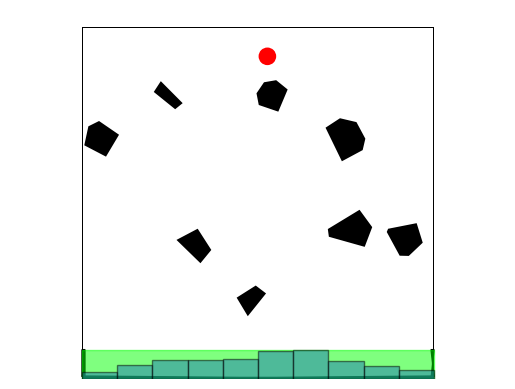

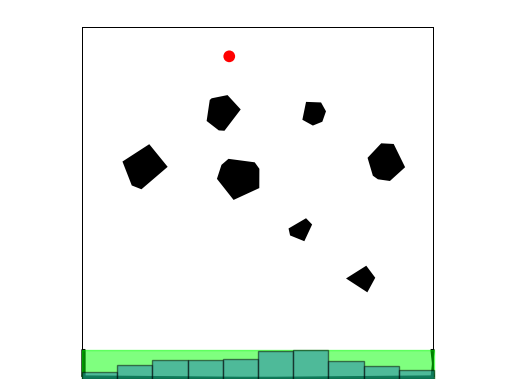

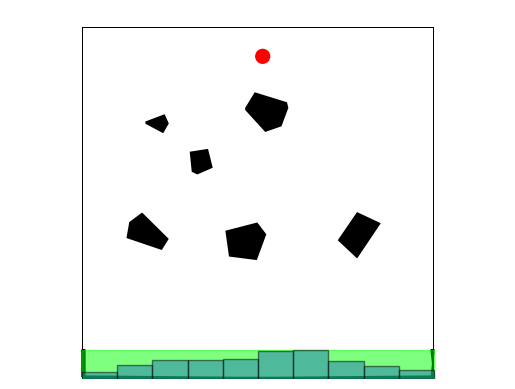

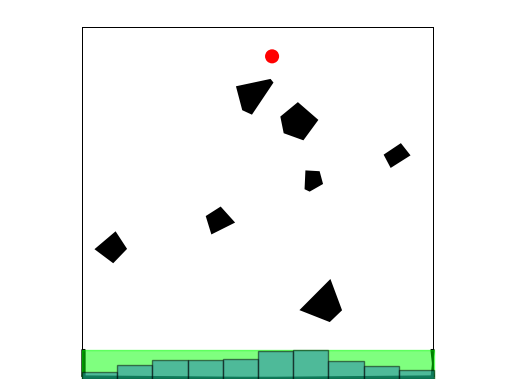

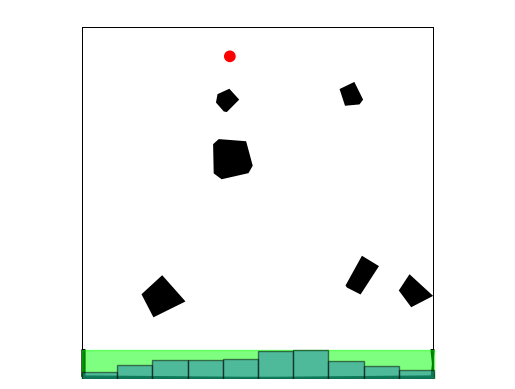

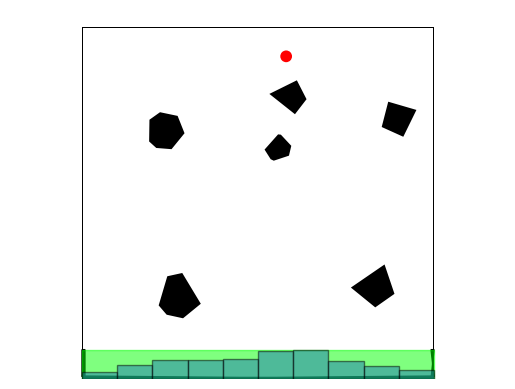

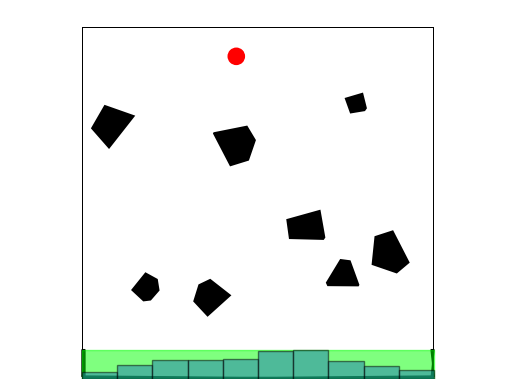

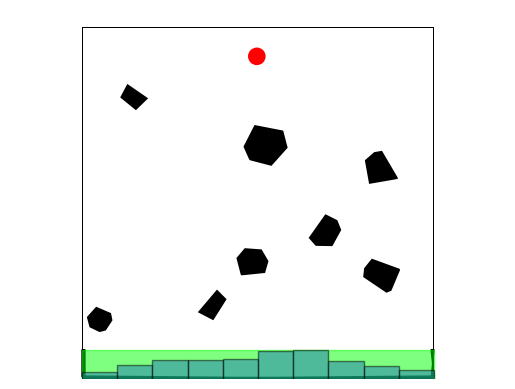

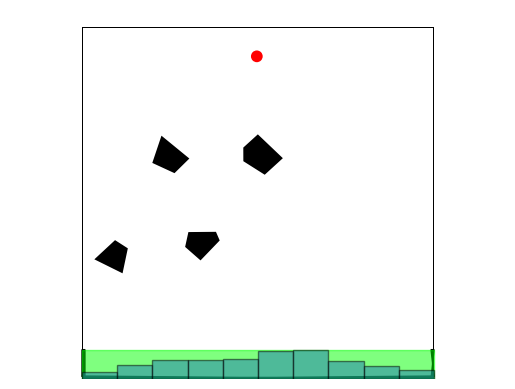

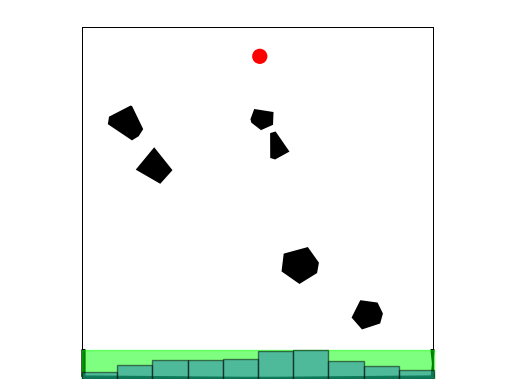

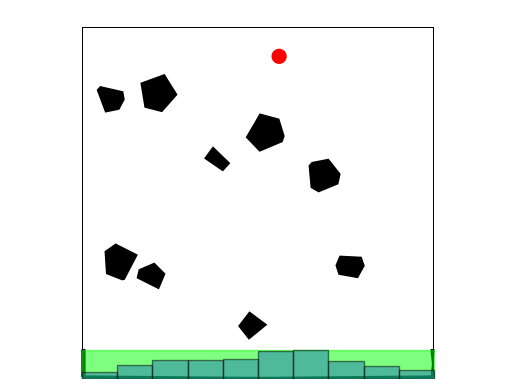

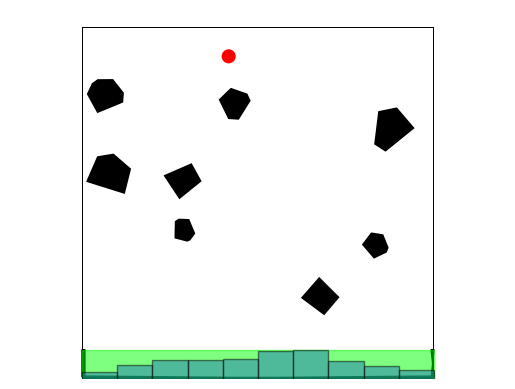

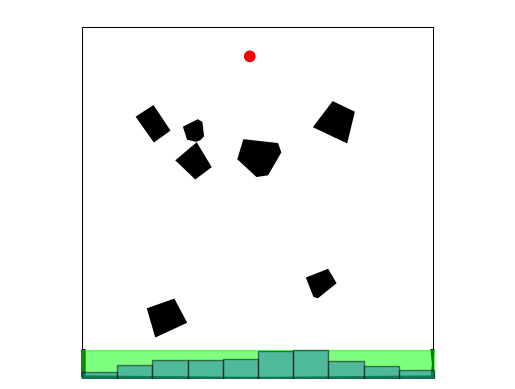

In [ ]:
for wname, w in worlds.items():
    plt.figure()
    viewer._draw_world_mpl(pgw.loadFromDict(w["world"]))
    draw_predictions(world_predictions[wname])
    plt.gca().autoscale_view()
    plt.axis("equal")
    plt.axis("off")

In [47]:
noisysim_pars = {
    "noise_position_static": 0.0,
    # "noise_position_moving": 10.0,
    # "noise_collision_direction": 0.78,
    # "noise_collision_elasticity": 0.67,
    "noise_position_moving": 6.67,
    "noise_collision_direction": 0.2,
    "noise_collision_elasticity": 0.7,
    # "noise_position_moving": 5.0,
    "noise_gravity": 0.0,
}

In [48]:
model_sims = {}
model_predictions = {}
n_sims = 500
for wname, w in worlds.items():
    print(wname)
    world = pgw.loadFromDict(w["world"])
    sims = simulate_noisypaths(world, 1 / 60, N=n_sims, **noisysim_pars)

    endpos = [p["path"]["FOCUS"][-1][0] for p in sims]
    bads = [i for i in range(n_sims) if endpos[i] < 0 or endpos[i] > 600]
    sims = [sims[i] for i in range(n_sims) if i not in bads]
    endpos = [endpos[i] for i in range(n_sims) if i not in bads]
    model_sims[wname] = sims
    model_predictions[wname] = endpos


lh_ll_unlink_plinko_0091
lh_hl_unlink_plinko_0110
hh_hl_unlink_plinko_0315
lh_hl_unlink_plinko_0049
hh_hl_unlink_plinko_0269
lh_ll_unlink_plinko_0155
hh_hl_unlink_plinko_0246
hh_hl_unlink_plinko_0202
lh_ll_unlink_plinko_0060
lh_hl_unlink_plinko_0036
hh_hl_unlink_plinko_0393
hh_hl_unlink_plinko_0240
lh_hl_unlink_plinko_0111
hh_hl_unlink_plinko_0252
hh_hl_unlink_plinko_0105
lh_ll_unlink_plinko_0217


In [55]:
print(world.objects["_LeftWall"].elasticity)
print(world.objects["topbump_0"].elasticity)

0.5
0.5


In [49]:
reload(viewer)

<module 'pyGameWorld.viewer' from '/Users/tony/repos/physics_events/data/exp1/pyGameWorld/viewer/__init__.py'>

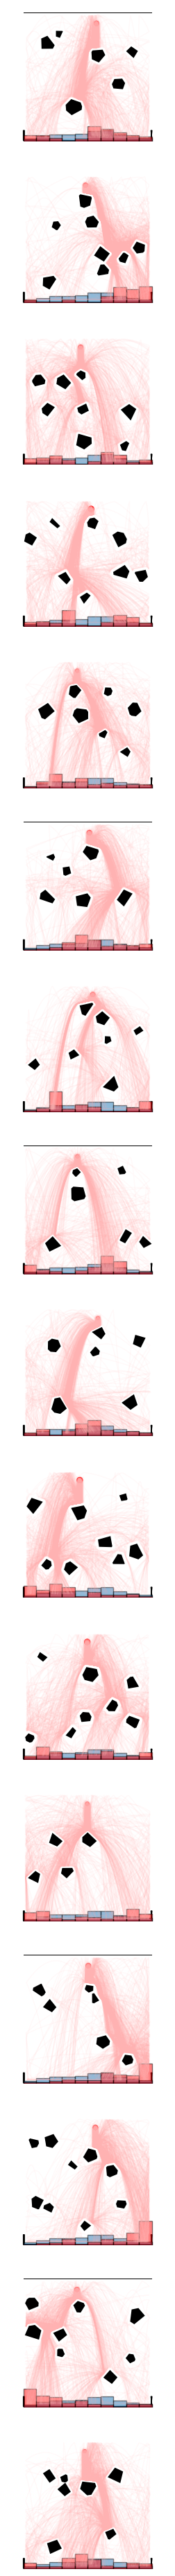

In [50]:
plt.figure(figsize=(3, 3 * len(worlds)))
for i, (wname, w) in enumerate(worlds.items()):
    plt.subplot(len(worlds), 1, i + 1)
    world = pgw.loadFromDict(w["world"])
    viewer._draw_paths_mpl(world, [p["path"] for p in model_sims[wname]], pathSize=1, alpha=0.075, draw_end=False)
    viewer._draw_world_mpl(world, obj_colors={"goal_0": (255, 255, 255, 0)})
    draw_predictions(world_predictions[wname])
    draw_predictions(model_predictions[wname], color="red")
    plt.gca().autoscale_view()
    plt.axis("equal")
    plt.axis("off")